# 04 — TF-IDF Analysis

Investigates how term richness and vocabulary specificity vary across popularity deciles.
All heavy computation is sampled and cached in `metadata.json`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent))
from notebooks.retrieval_gold_document_eval.shared_setup import *

✓ Boundaries loaded (UW: 1.0000…175763168.0000)
  ✓ BM25+: loading from cache
    excluded 2,654 rows matching EXCLUDED_DATASETS (['hotpot_qa', 'trex'])
  ✓ FAISS high: loading from cache
    excluded 2,654 rows matching EXCLUDED_DATASETS (['hotpot_qa', 'trex'])
  ✓ FAISS hybrid: loading from cache
    excluded 2,654 rows matching EXCLUDED_DATASETS (['hotpot_qa', 'trex'])
✓ Metrics loaded from cache
✓ Per-decile metrics loaded from cache

✓ shared_setup complete — 3 strategies ready
  Corpus root: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil
  Results dir: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k
    'BM25+' (key=retrieved_docs_bm25_plus)
    'FAISS high' (key=retrieved_docs_ivfpq_high)
    'FAISS hybrid' (key=retrieved_docs_faiss_hybrid)
  Decile mode: chunk_weighted
  Group col  : dataset


## TF-IDF Distribution Per Decile (Corpus-Wide)

✓ Loaded TF-IDF stats from metadata.json [chunk (size=1000, overlap=100) level, cached v3]

 Decile  src_docs  n_chunks  mean_unique_terms   mean_tfidf   mean_idf  vocab_cov
      1       20000      29330               45.4       0.1237     4.9550     0.7658
      2       20000      48124               60.3       0.1108     5.1171     0.9136
      3       20000      64316               64.0       0.1082     5.1410     0.9536
      4       20000      78214               66.3       0.1067     5.1548     0.9721
      5       20000      96549               67.8       0.1058     5.1934     0.9836
      6       20000     118325               68.9       0.1050     5.1847     0.9896
      7       20000     150378               69.7       0.1044     5.1906     0.9937
      8       20000     195321               70.5       0.1039     5.1855     0.9962
      9       20000     283856               71.5       0.1032     5.1913     0.9978
     10       20000     499811               72.7       0.102

✓ Saved → /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k/eval_results/tfidf_distribution_per_decile.png
✓ Saved → tfidf_distribution_per_decile.png


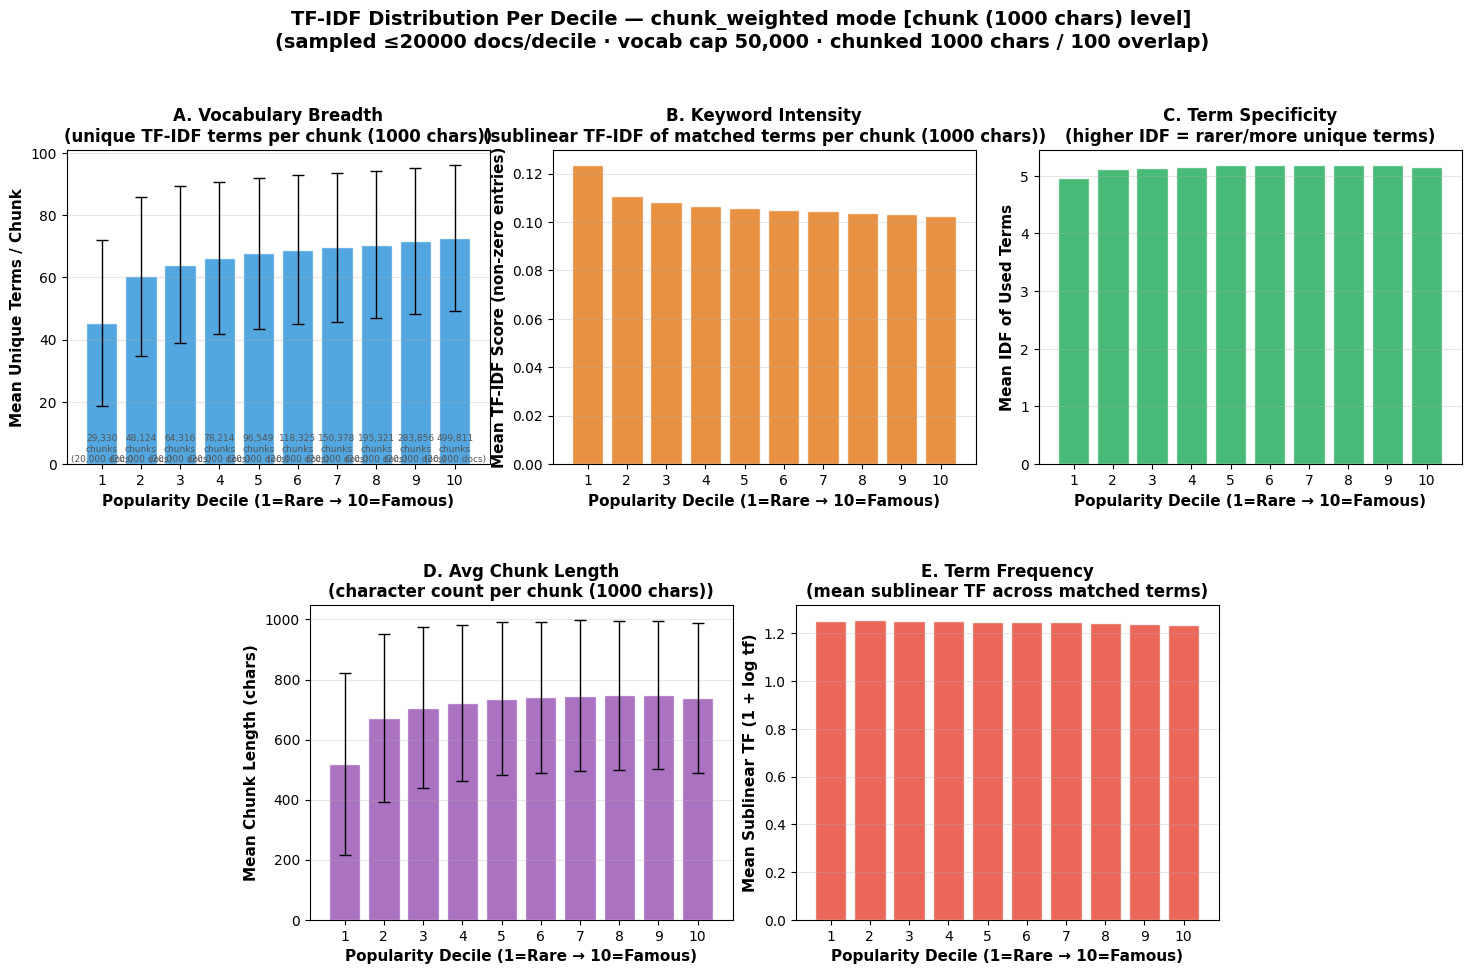

In [2]:
from src.metrics.tfidf_service import (
    load_or_compute_tfidf_stats,
    print_tfidf_stats,
    plot_tfidf_stats,
)
from src.metrics.decile_utils import boundaries_for

TFIDF_SAMPLE_PER_DECILE = 20_000
TFIDF_MAX_FEATURES      = 50_000

boundaries = boundaries_for(DECILE_MODE, boundaries_uw, boundaries_cw)

tfidf_stats = load_or_compute_tfidf_stats(
    metadata_path=metadata_path,
    corpus_path=CORPUS_PATH,
    boundaries=boundaries,
    sample_per_decile=TFIDF_SAMPLE_PER_DECILE,
    max_features=TFIDF_MAX_FEATURES,
    chunk_size=1000,
    chunk_overlap=100,
)

print_tfidf_stats(tfidf_stats)

plot_tfidf_stats(
    tfidf_stats,
    decile_mode=DECILE_MODE,
    sample_per_decile=TFIDF_SAMPLE_PER_DECILE,
    max_features=TFIDF_MAX_FEATURES,
    out_path=IMAGES_DIR / 'tfidf_distribution_per_decile.png',
    chunk_overlap=100,
    chunk_size=1000,
)
print('✓ Saved → tfidf_distribution_per_decile.png')

## TF-IDF Per Decile — Per Dataset Breakdown

Loading corpus-wide TF-IDF vectorizer…


✓ Loading corpus vectorizer from cache: tfidf_vectorizer_decile_tfidf_stats_chunks_1000_100_n20000_vocab50000.pkl
  Fetching 4,174 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 4,174 / 4,174 IDs in corpus


  Transforming 59,319 texts with corpus vectorizer (vocab=50,000)…


  Vocabulary in use: 50,000 terms


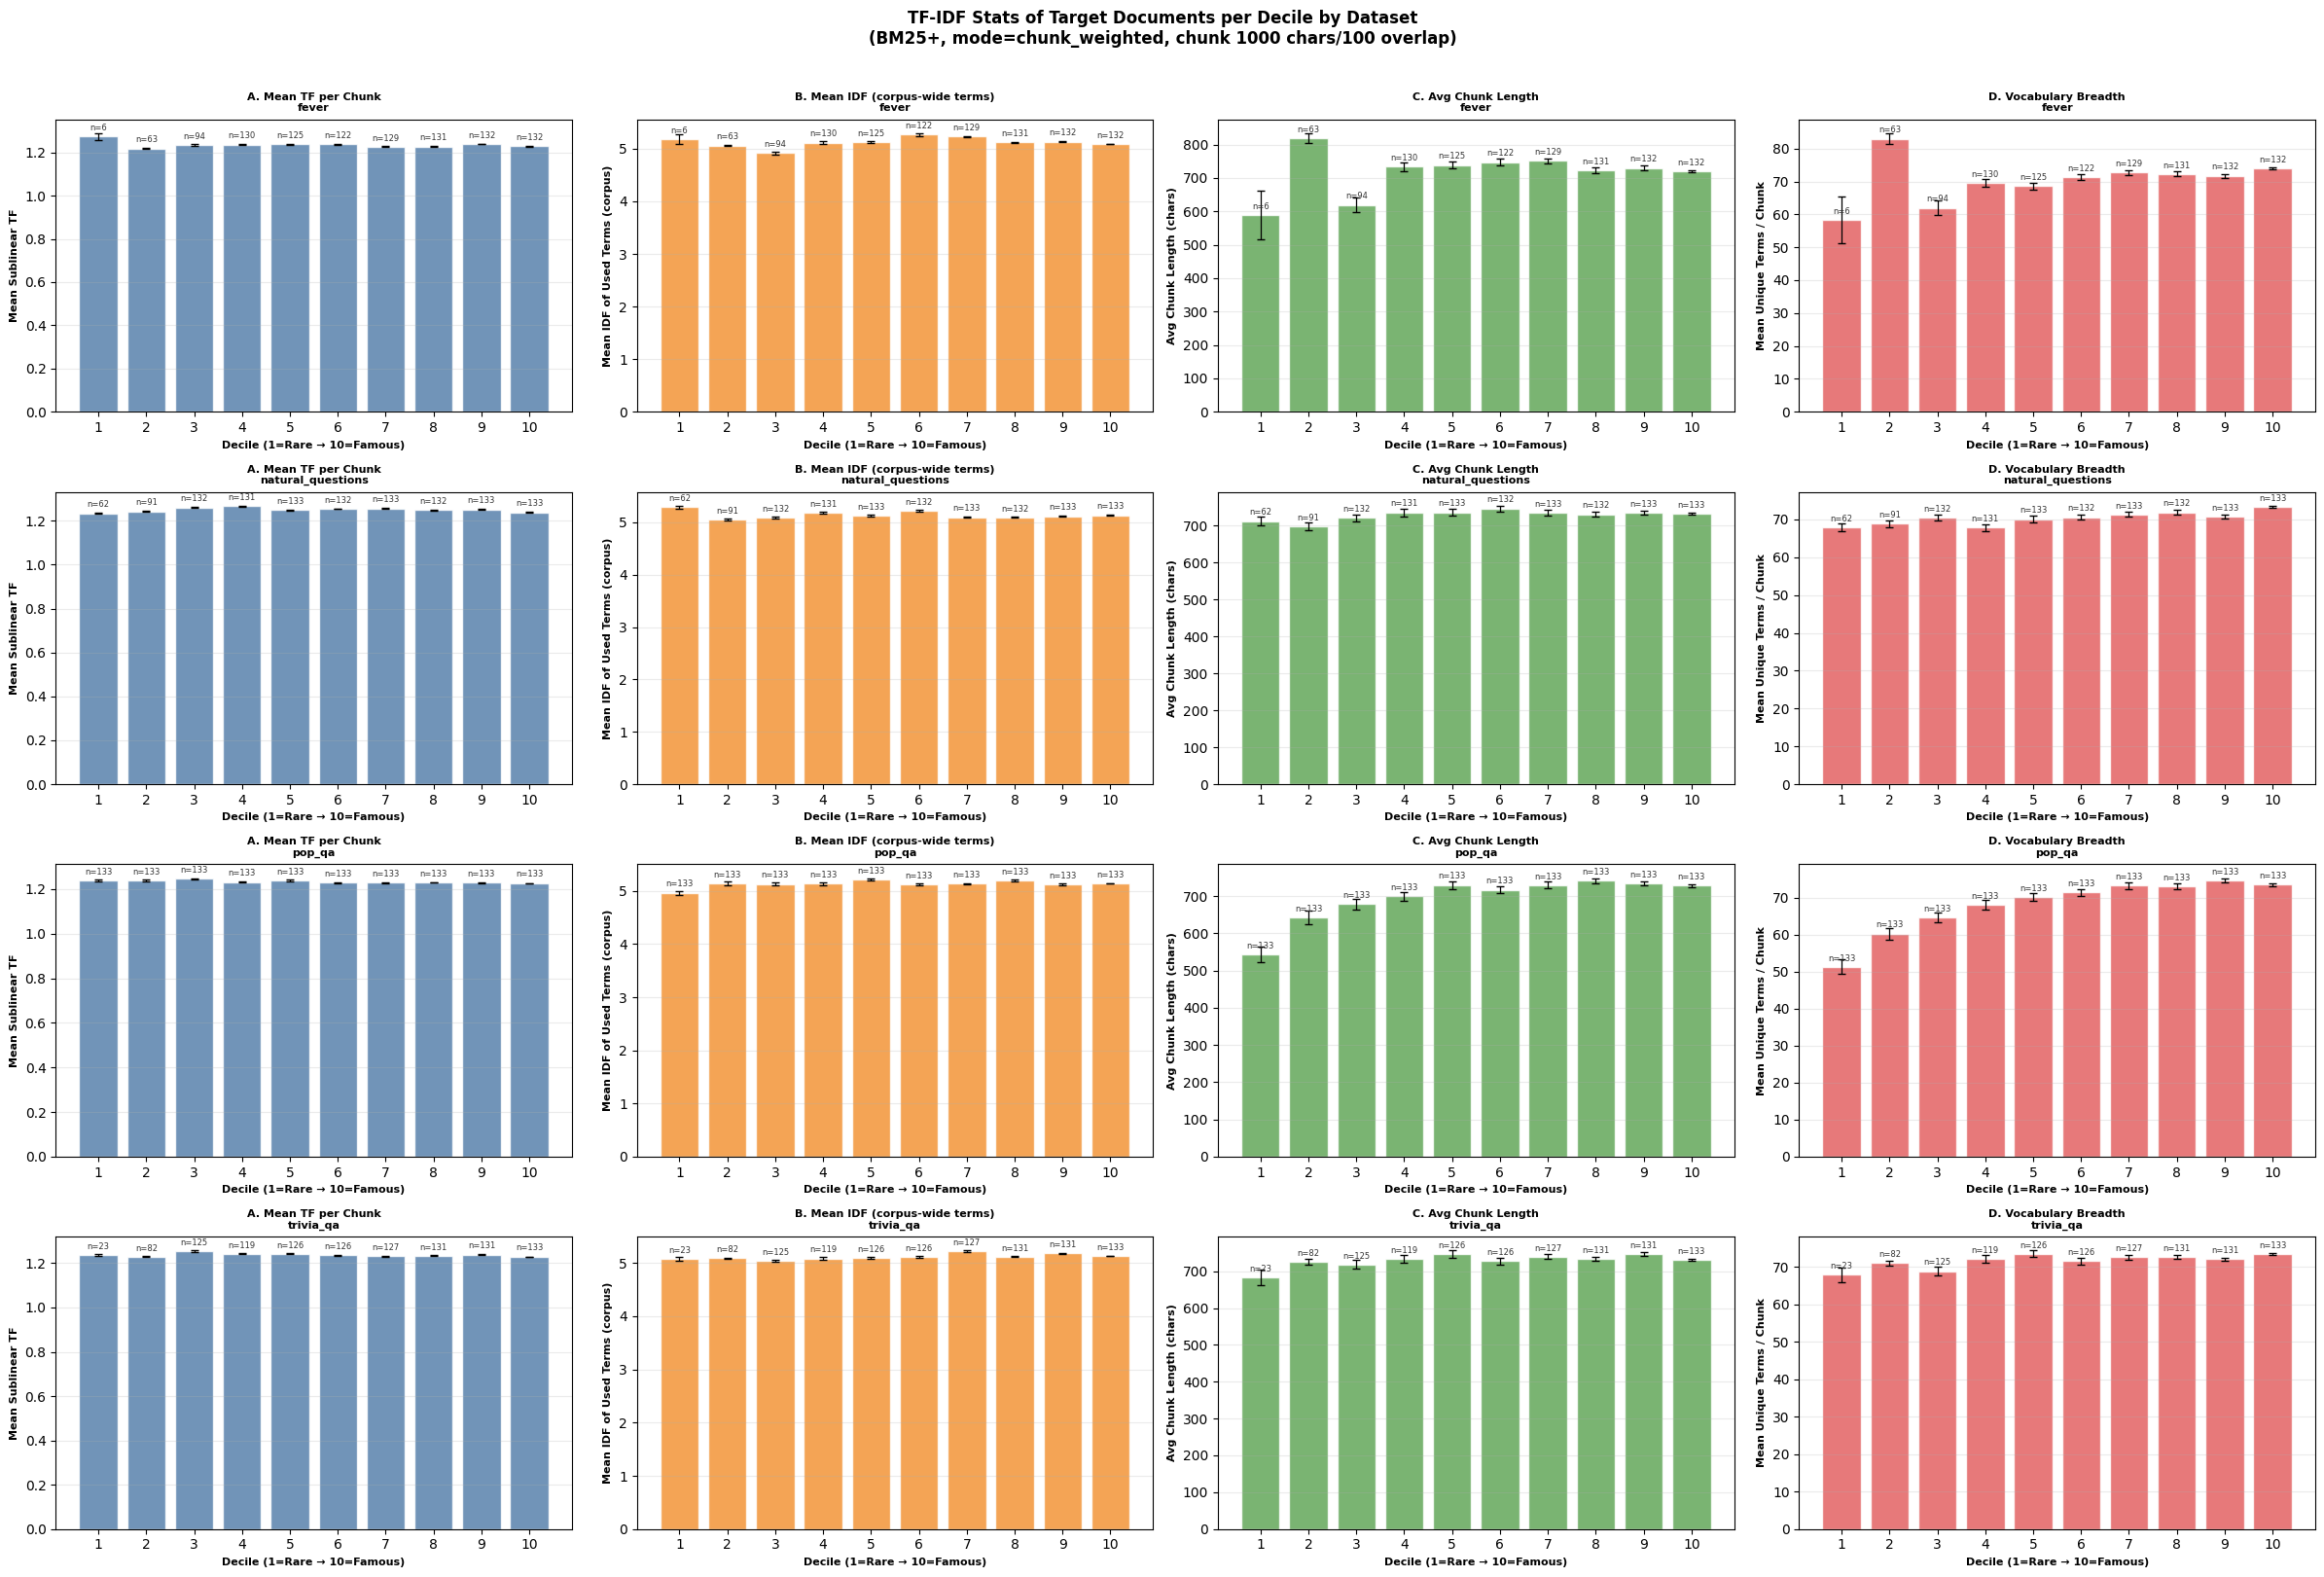

✓ Saved → tfidf_per_dataset_retrieved_docs_bm25_plus.png
  Fetching 4,174 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 4,174 / 4,174 IDs in corpus


  Transforming 59,319 texts with corpus vectorizer (vocab=50,000)…


  Vocabulary in use: 50,000 terms


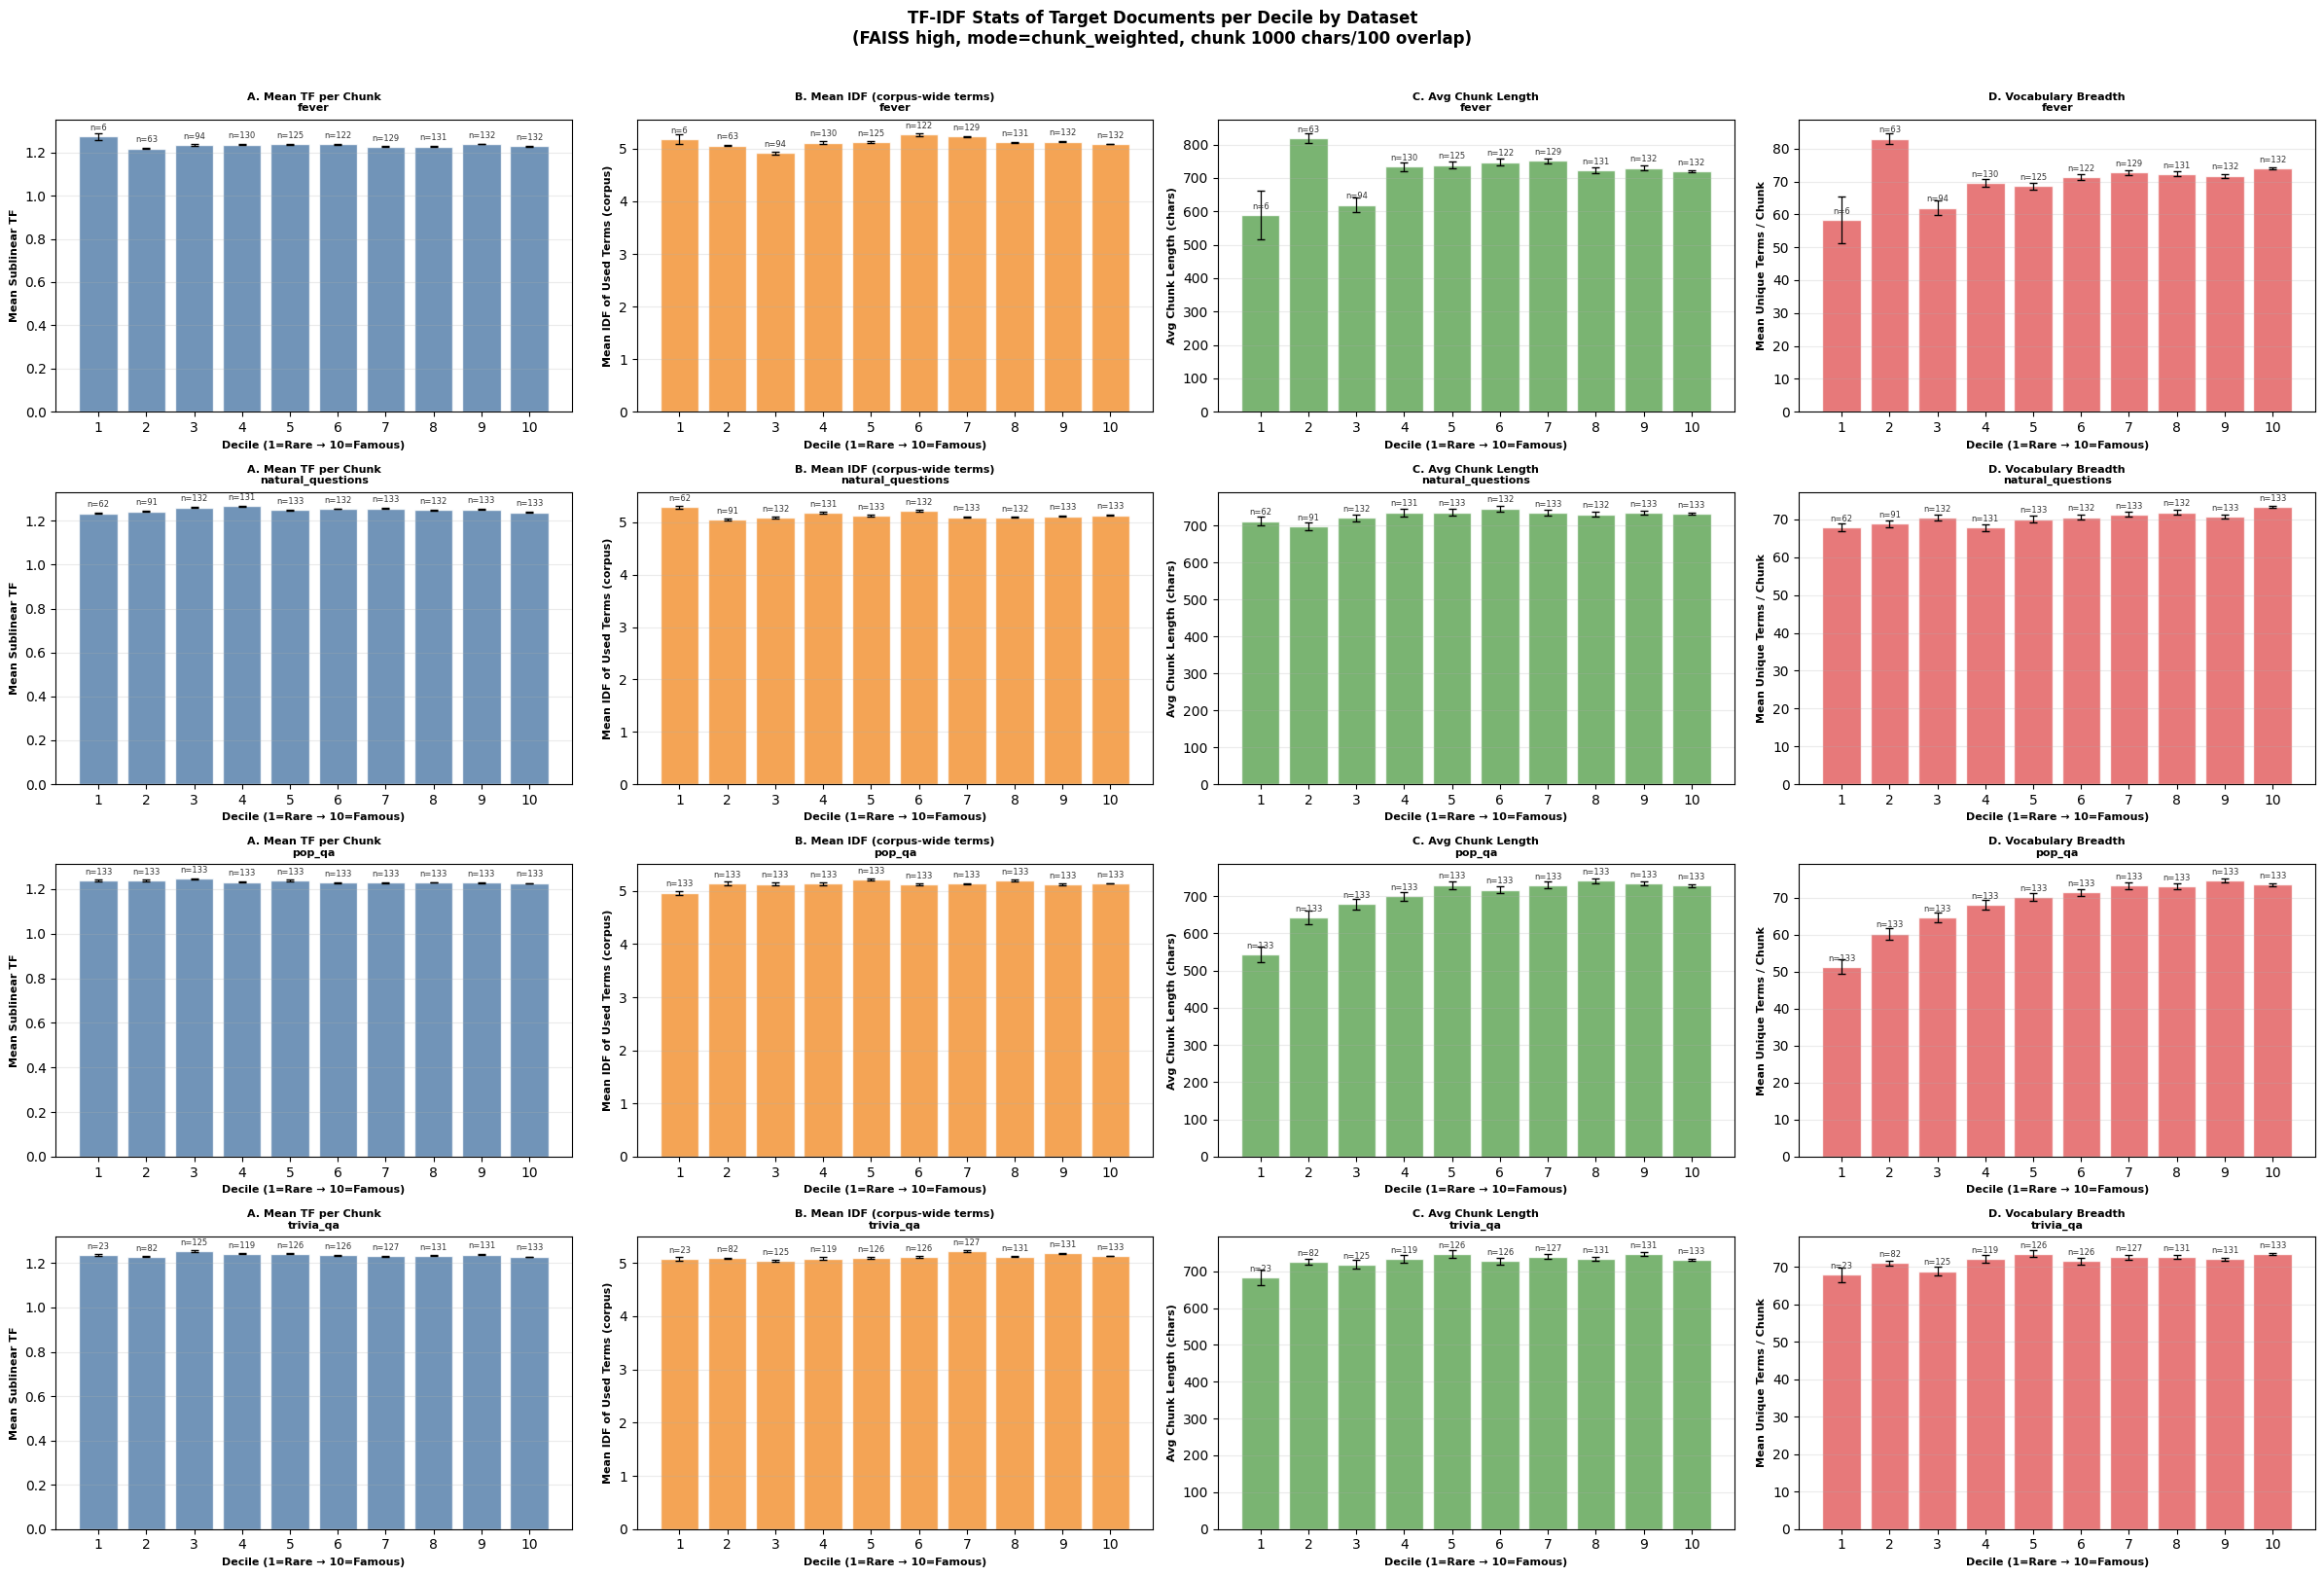

✓ Saved → tfidf_per_dataset_retrieved_docs_ivfpq_high.png
  Fetching 4,174 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 4,174 / 4,174 IDs in corpus


  Transforming 59,319 texts with corpus vectorizer (vocab=50,000)…


  Vocabulary in use: 50,000 terms


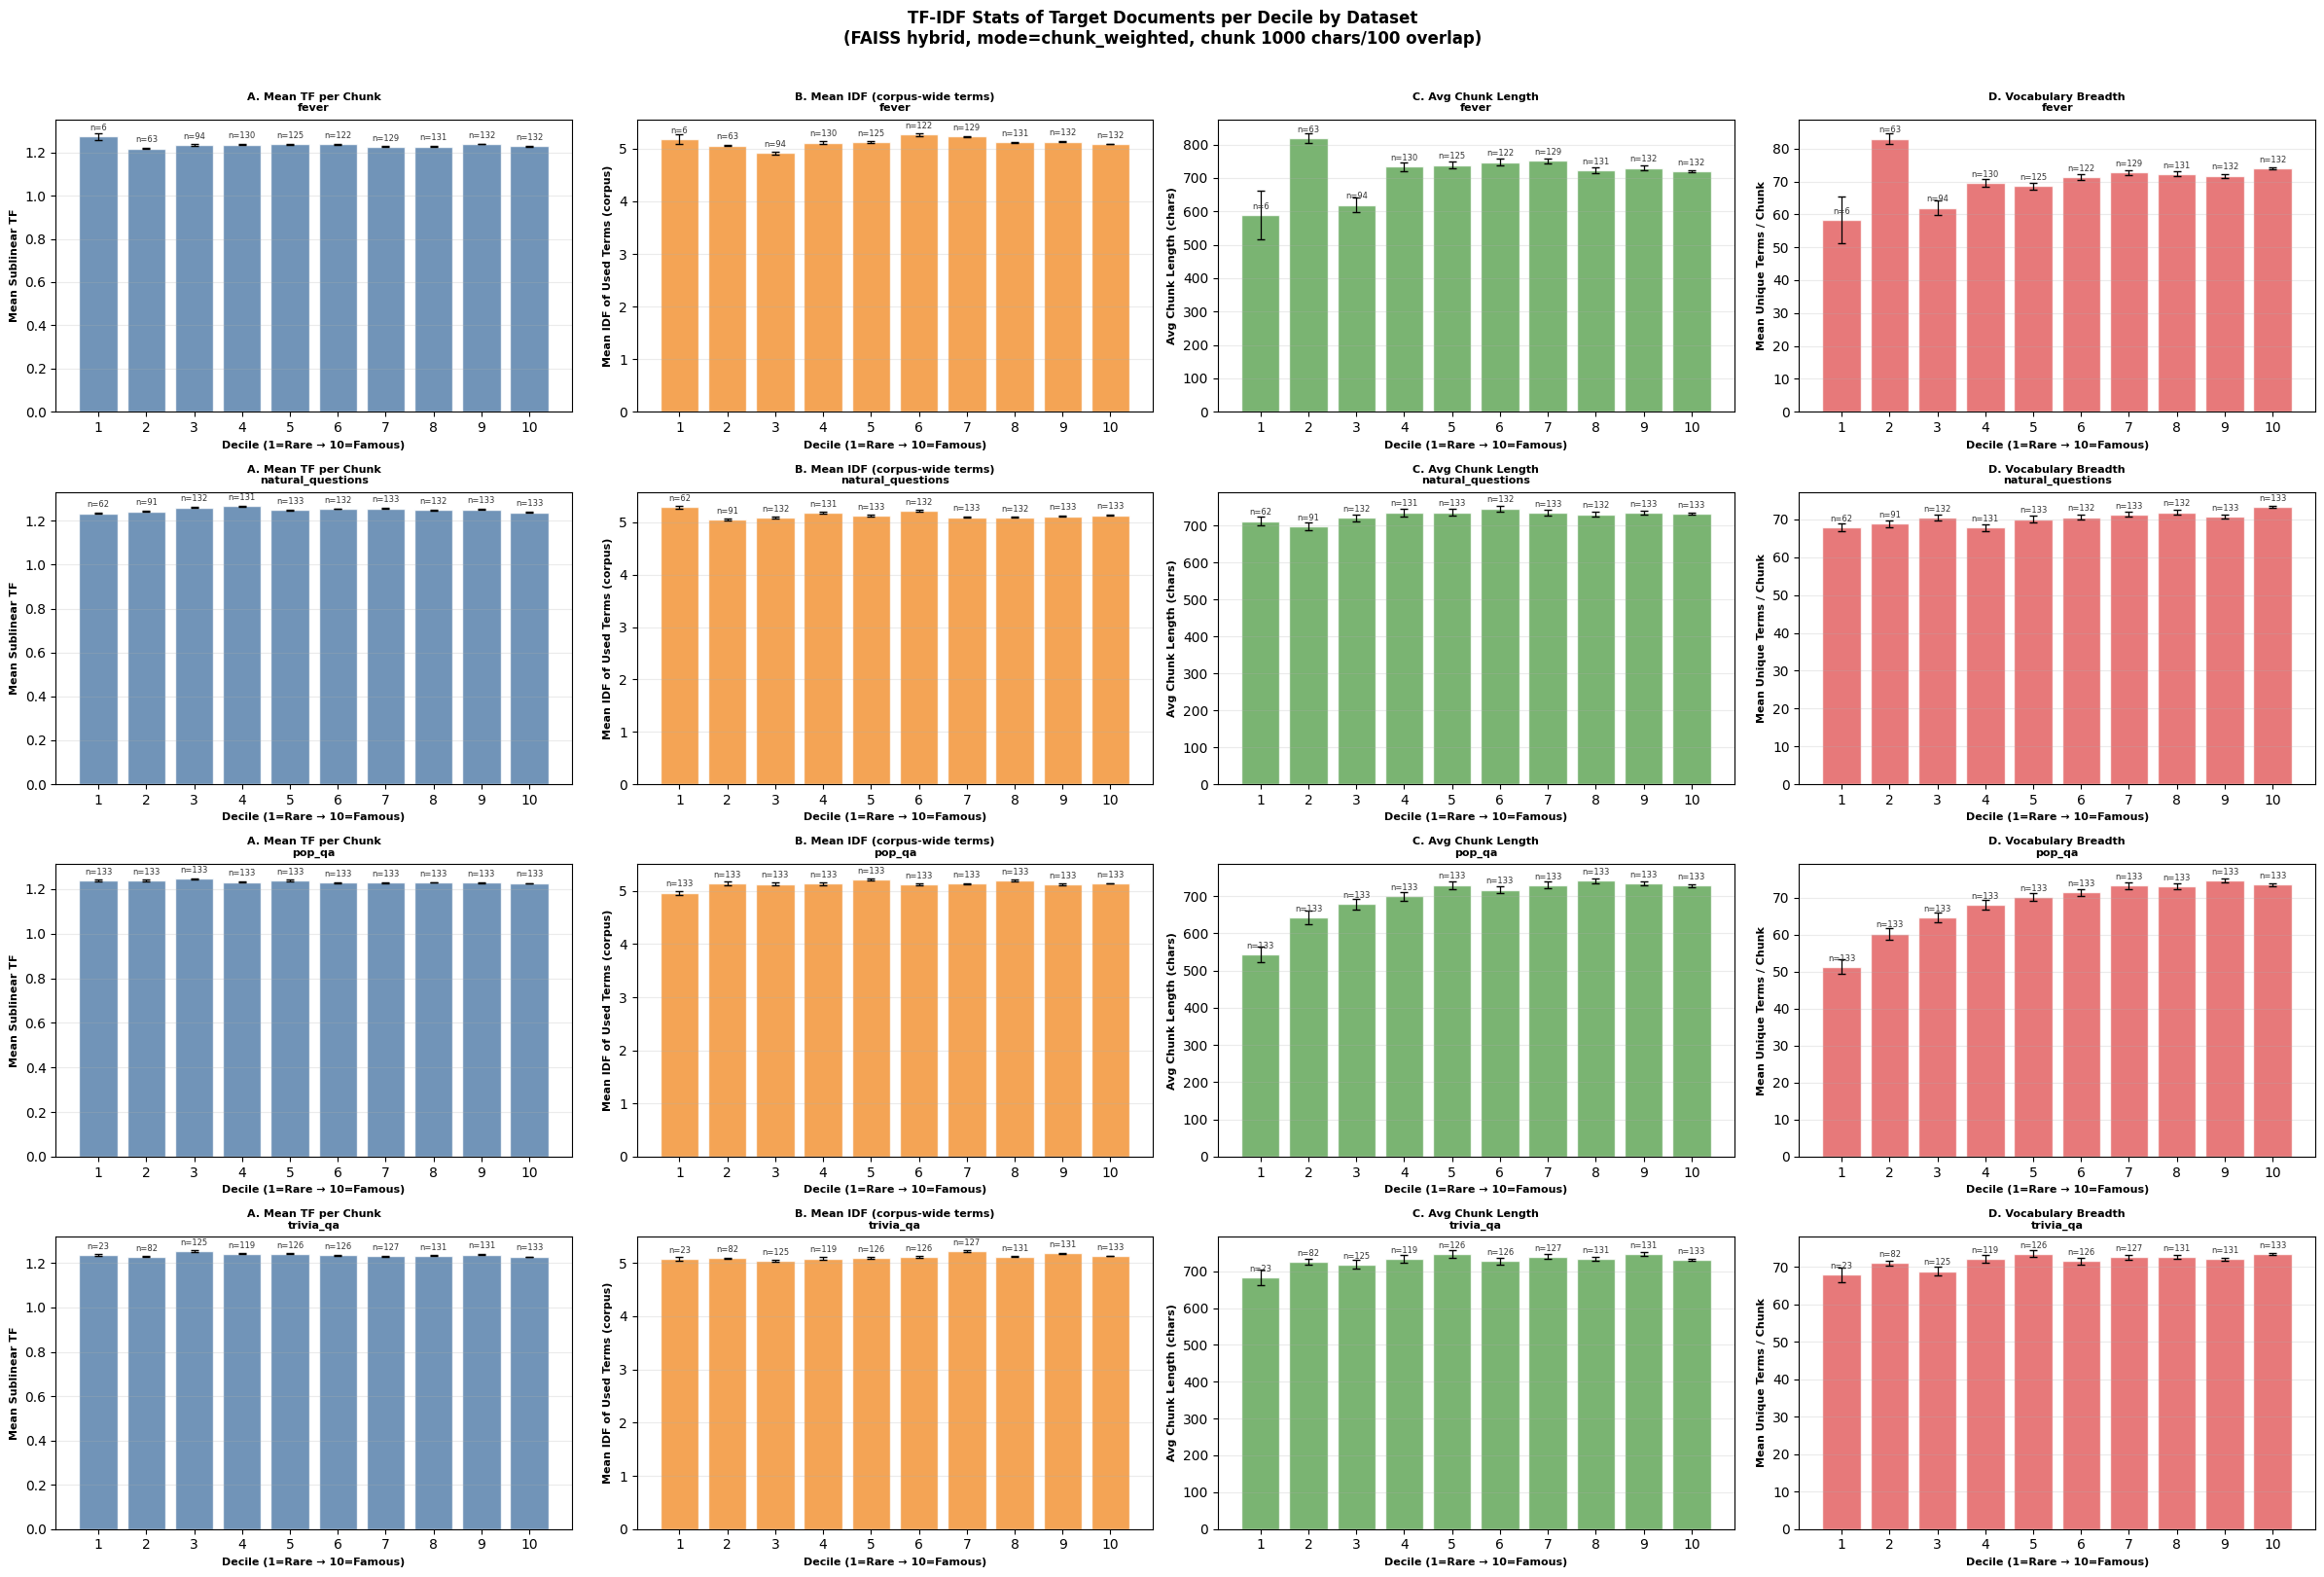

✓ Saved → tfidf_per_dataset_retrieved_docs_faiss_hybrid.png


In [3]:
from src.metrics.tfidf_service import (
    load_or_compute_corpus_vectorizer,
    compute_tfidf_stats_for_ids,
)

CHUNK_SIZE    = 1000
CHUNK_OVERLAP = 100
MAX_FEATURES  = 50_000
SAMPLE        = 20_000

print('Loading corpus-wide TF-IDF vectorizer…')
corpus_vec = load_or_compute_corpus_vectorizer(
    metadata_path=metadata_path,
    corpus_path=CORPUS_PATH,
    boundaries=boundaries,
    sample_per_decile=SAMPLE,
    max_features=MAX_FEATURES,
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)

PANEL_CFG = [
    ('mean_tf_score',          'Mean Sublinear TF',               'A. Mean TF per Chunk',            '#4e79a7'),
    ('mean_idf_of_used_terms', 'Mean IDF of Used Terms (corpus)', 'B. Mean IDF (corpus-wide terms)', '#f28e2b'),
    ('mean_chunk_length',      'Avg Chunk Length (chars)',         'C. Avg Chunk Length',             '#59a14f'),
    ('mean_unique_terms',      'Mean Unique Terms / Chunk',        'D. Vocabulary Breadth',           '#e15759'),
]
SE_MAP = {
    'mean_tf_score':          'se_tf_score',
    'mean_idf_of_used_terms': 'se_idf_of_used_terms',
    'mean_chunk_length':      'se_chunk_length',
    'mean_unique_terms':      'se_unique_terms',
}
d_idx = list(range(1, 11))

for strategy in ALL_STRATEGIES:
    df = results_by_strategy[strategy]
    if not GROUP_COL or GROUP_COL not in df.columns:
        print(f'⚠ No group column for {strategy_label(strategy)} — skipping per-dataset breakdown')
        continue

    per_group_stats = compute_tfidf_stats_for_ids(
        query_df=df[['wikipedia_id', decile_col, GROUP_COL]],
        corpus_path=CORPUS_PATH,
        decile_col=decile_col,
        group_col=GROUP_COL,
        corpus_vectorizer=corpus_vec,
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
    )

    datasets = sorted(per_group_stats.keys())
    if not datasets:
        continue

    fig, axes = plt.subplots(len(datasets), 4,
                             figsize=(24, 4 * len(datasets)), squeeze=False)

    for row_idx, ds in enumerate(datasets):
        ds_stats = per_group_stats[ds]
        sub = df[df[GROUP_COL].astype(str) == ds]
        q_counts = [int((sub[decile_col] == d).sum()) for d in range(10)]

        for col_idx, (stat_key, ylabel, panel_label, color) in enumerate(PANEL_CFG):
            ax = axes[row_idx, col_idx]
            vals = [ds_stats[d].get(stat_key, float('nan')) if d in ds_stats else float('nan')
                    for d in range(10)]
            err_key = SE_MAP.get(stat_key)
            errs = ([ds_stats[d].get(err_key, 0.0) if d in ds_stats else 0.0 for d in range(10)]
                    if err_key else None)

            ax.bar(d_idx, vals, color=color, alpha=0.80, edgecolor='white', linewidth=1)
            if errs:
                ax.errorbar(d_idx, vals, yerr=errs, fmt='none', color='black',
                            capsize=3, linewidth=1.2, elinewidth=0.9)
            y_max = max((v for v in vals if v == v), default=1.0)
            for xi, v, qc in zip(d_idx, vals, q_counts):
                if qc > 0:
                    ax.text(xi, (v if v == v else 0.0) + y_max * 0.015,
                            f'n={qc}', ha='center', va='bottom', fontsize=6, color='#333')
            ax.set_xlabel('Decile (1=Rare → 10=Famous)', fontsize=8, fontweight='bold')
            ax.set_ylabel(ylabel, fontsize=8, fontweight='bold')
            ax.set_title(f'{panel_label}\n{ds}', fontsize=8, fontweight='bold')
            ax.set_xticks(d_idx)
            ax.grid(axis='y', alpha=0.25)

    fig.suptitle(
        f'TF-IDF Stats of Target Documents per Decile by Dataset\n'
        f'({strategy_label(strategy)}, mode={DECILE_MODE}, '
        f'chunk {CHUNK_SIZE} chars/{CHUNK_OVERLAP} overlap)',
        fontsize=12, fontweight='bold', y=1.01,
    )
    plt.tight_layout()
    out = IMAGES_DIR / f'tfidf_per_dataset_{strategy}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved → {out.name}')

## TF-IDF Trend — % Change vs Grand-Mean Baseline

  Fetching 4,174 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 4,174 / 4,174 IDs in corpus


  Transforming 59,319 texts with corpus vectorizer (vocab=50,000)…


  Vocabulary in use: 50,000 terms


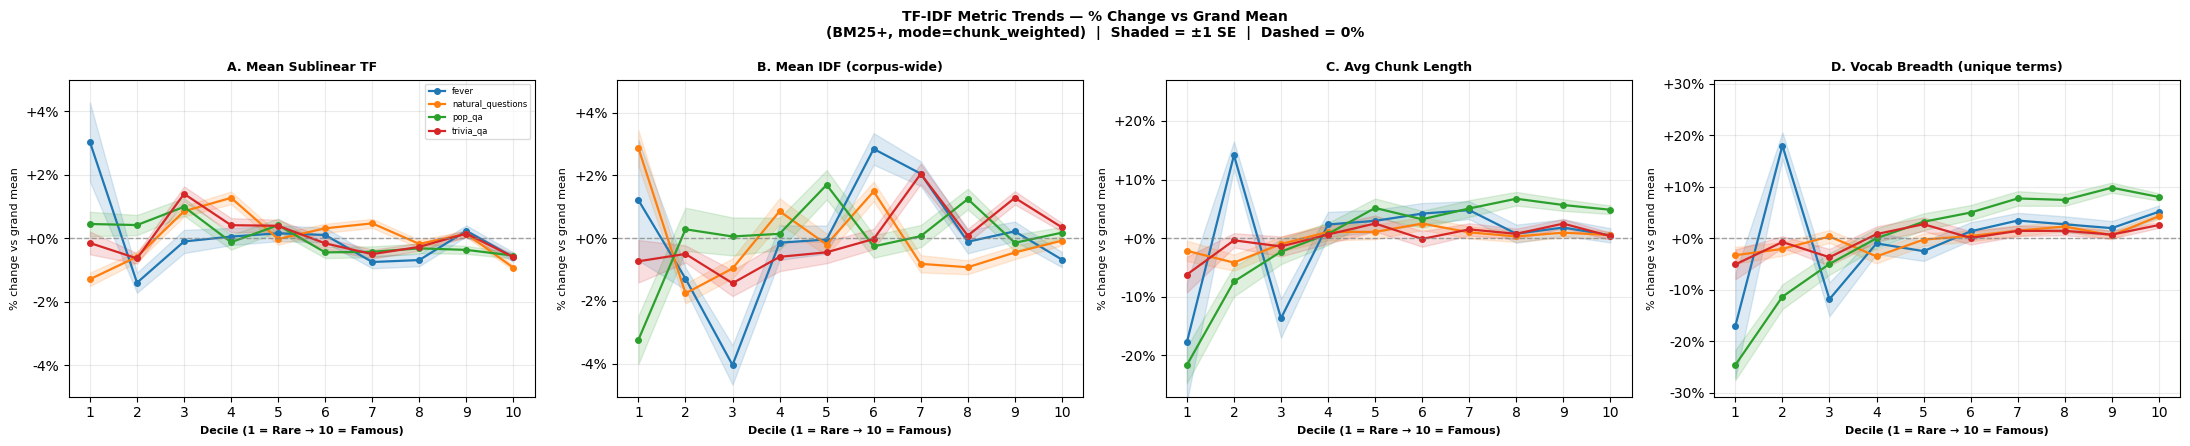

✓ Saved → tfidf_trend_pct_retrieved_docs_bm25_plus.png
  Fetching 4,174 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 4,174 / 4,174 IDs in corpus


  Transforming 59,319 texts with corpus vectorizer (vocab=50,000)…


  Vocabulary in use: 50,000 terms


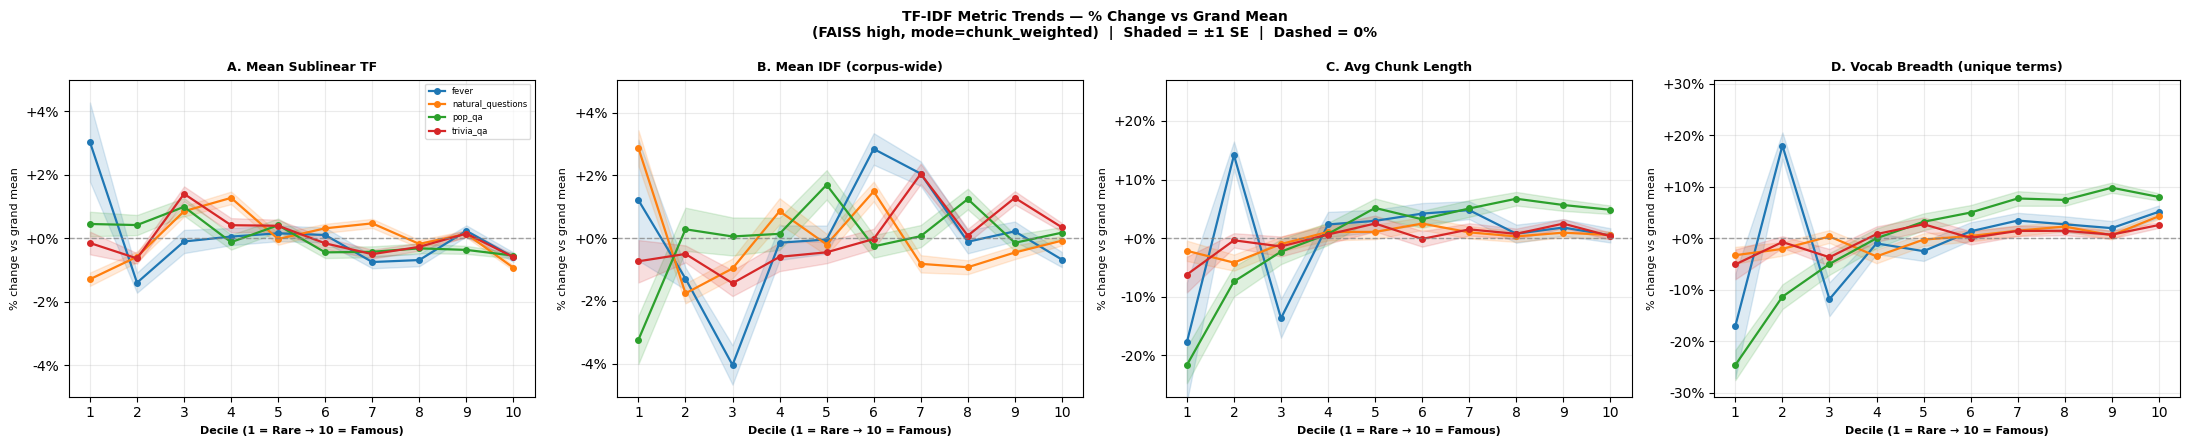

✓ Saved → tfidf_trend_pct_retrieved_docs_ivfpq_high.png
  Fetching 4,174 unique document IDs from corpus…


Scanning corpus: 0it [00:00, ?it/s]

  Matched 4,174 / 4,174 IDs in corpus


  Transforming 59,319 texts with corpus vectorizer (vocab=50,000)…


  Vocabulary in use: 50,000 terms


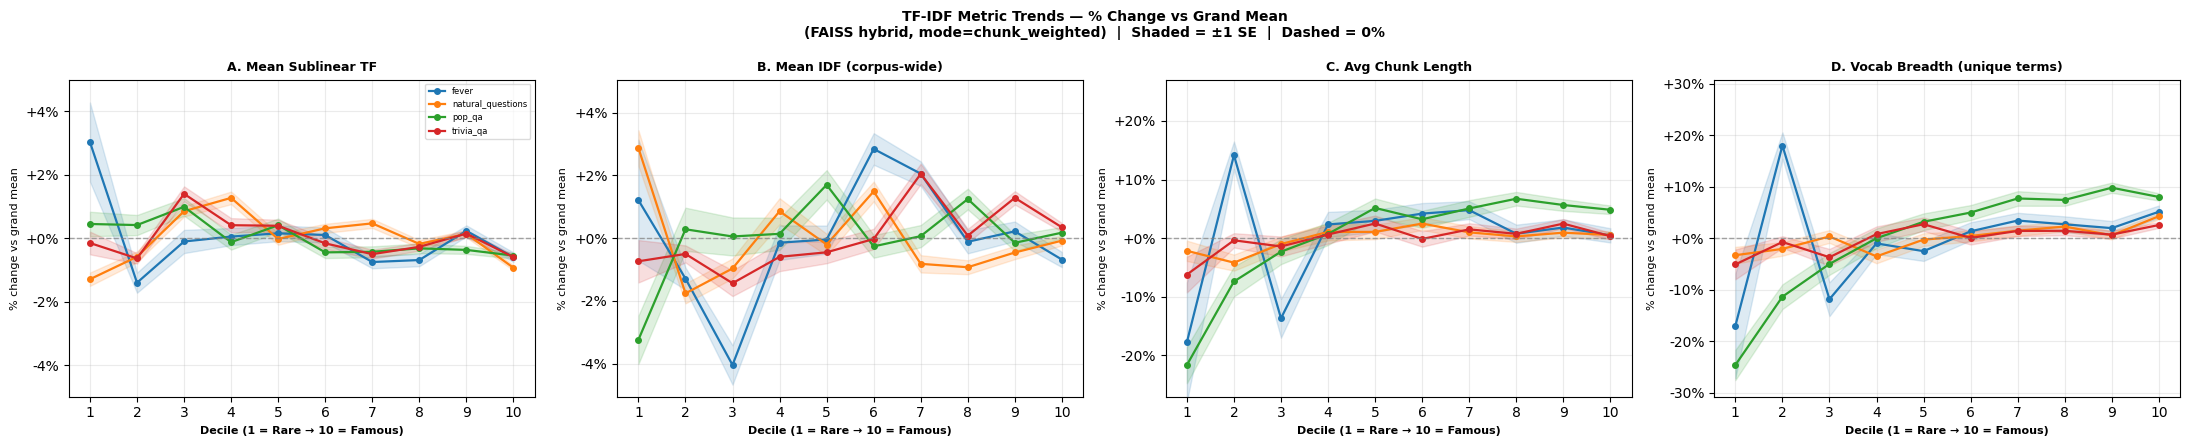

✓ Saved → tfidf_trend_pct_retrieved_docs_faiss_hybrid.png


In [4]:
TREND_PANELS = [
    ('mean_tf_score',          'se_tf_score',          '% change vs grand mean', 'A. Mean Sublinear TF',           '#4e79a7'),
    ('mean_idf_of_used_terms', 'se_idf_of_used_terms', '% change vs grand mean', 'B. Mean IDF (corpus-wide)',      '#f28e2b'),
    ('mean_chunk_length',      'se_chunk_length',      '% change vs grand mean', 'C. Avg Chunk Length',            '#59a14f'),
    ('mean_unique_terms',      'se_unique_terms',      '% change vs grand mean', 'D. Vocab Breadth (unique terms)', '#e15759'),
]

for strategy in ALL_STRATEGIES:
    df = results_by_strategy[strategy]
    if not GROUP_COL or GROUP_COL not in df.columns:
        continue

    pgs = compute_tfidf_stats_for_ids(
        query_df=df[['wikipedia_id', decile_col, GROUP_COL]],
        corpus_path=CORPUS_PATH,
        decile_col=decile_col,
        group_col=GROUP_COL,
        corpus_vectorizer=corpus_vec,
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
    )

    datasets = sorted(pgs.keys())
    if not datasets:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
    cmap = plt.get_cmap('tab10')

    for col_idx, (stat_key, se_key, ylabel, panel_label, _color) in enumerate(TREND_PANELS):
        ax = axes[col_idx]
        all_pct = []
        for ds_idx, ds in enumerate(datasets):
            ds_stats = pgs[ds]
            color = cmap(ds_idx % 10)
            vals = np.array([ds_stats[d].get(stat_key, np.nan) if d in ds_stats else np.nan
                             for d in range(10)], dtype=float)
            errs = np.array([ds_stats[d].get(se_key, 0.0) if d in ds_stats else 0.0
                             for d in range(10)], dtype=float)
            finite = np.isfinite(vals)
            if not finite.any():
                continue
            baseline = float(np.nanmean(vals))
            if baseline == 0.0:
                continue
            se_mean = float(np.sqrt(np.nansum(errs ** 2))) / float(finite.sum())
            pct = (vals - baseline) / abs(baseline) * 100.0
            pct_err = np.sqrt(errs ** 2 + se_mean ** 2) / abs(baseline) * 100.0
            all_pct.extend(pct[np.isfinite(pct)].tolist())
            ax.plot(d_idx, pct, marker='o', markersize=4, linewidth=1.6, color=color, label=ds)
            ax.fill_between(d_idx, pct - pct_err, pct + pct_err, alpha=0.15, color=color)

        ax.axhline(0.0, color='grey', linewidth=1.0, linestyle='--', alpha=0.7)
        if all_pct:
            margin = max(abs(np.nanmax(all_pct)), abs(np.nanmin(all_pct))) * 1.25
            ax.set_ylim(-max(margin, 5.0), max(margin, 5.0))
        ax.set_xlabel('Decile (1 = Rare → 10 = Famous)', fontsize=8, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_title(panel_label, fontsize=9, fontweight='bold')
        ax.set_xticks(d_idx)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
        ax.grid(alpha=0.25)
        if col_idx == 0:
            ax.legend(fontsize=6, loc='best', framealpha=0.7)

    fig.suptitle(
        f'TF-IDF Metric Trends — % Change vs Grand Mean\n'
        f'({strategy_label(strategy)}, mode={DECILE_MODE})'
        '  |  Shaded = ±1 SE  |  Dashed = 0%',
        fontsize=10, fontweight='bold',
    )
    plt.tight_layout()
    out = IMAGES_DIR / f'tfidf_trend_pct_{strategy}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved → {out.name}')

## BM25 Failure Factor Analysis

This section connects the document statistics above to BM25 performance. BM25 can only reward query terms that survive tokenisation, have high corpus IDF, and co-occur inside a retrievable target chunk. The IDF values here come from the cached corpus TF-IDF vectorizer, so treat them as an IDF proxy for query specificity rather than the exact BM25 index formula. If performance falls in high-popularity deciles, these panels test whether the cause is lower query specificity, longer/more fragmented target documents, weaker query-target overlap, or more diffuse evidence across chunks. Per-question estimates use 95% normal confidence intervals; fixed corpus statistics remain point estimates.

In [5]:
from src.metrics.bm25_analysis import (
    aggregate_bm25_lexical_factors,
    compute_bm25_lexical_factor_rows,
)

BM25_STRATEGY = next((s for s in ALL_STRATEGIES if 'bm25' in s.lower()), ALL_STRATEGIES[0])
bm25_df = results_by_strategy[BM25_STRATEGY].copy()
factor_cache = IMAGES_DIR.parent / f'bm25_lexical_factors_v2_{BM25_STRATEGY}_{DECILE_MODE}.parquet'

if factor_cache.exists() and not FORCE_RECOMPUTE:
    bm25_factors = pd.read_parquet(factor_cache)
    print(f'✓ Loaded BM25 lexical factors → {factor_cache.name}')
else:
    bm25_factors = compute_bm25_lexical_factor_rows(
        query_df=bm25_df,
        corpus_path=CORPUS_PATH,
        decile_col=decile_col,
        corpus_vectorizer=corpus_vec,
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        top_k=TOP_K,
    )
    bm25_factors.to_parquet(factor_cache, index=False)
    print(f'✓ Cached BM25 lexical factors → {factor_cache.name}')

FACTOR_METRIC_COLS = [
    'query_idf_mean', 'query_idf_sum', 'query_oov_rate', 'doc_length_chars',
    'n_chunks', 'doc_query_overlap_frac', 'doc_query_tf_sum',
    'doc_query_log_tf_sum', 'doc_query_tfidf_sum',
    'best_chunk_query_overlap_frac', 'best_chunk_query_idf_sum',
    'best_chunk_query_tf_sum', 'best_chunk_query_log_tf_sum',
    'best_chunk_query_tfidf_sum', 'matching_chunk_count', 'matching_chunk_frac',
]

factor_summary = (
    bm25_factors
    .groupby('decile', as_index=False)
    .agg(
        n=('wikipedia_id', 'size'),
        hit_at_1=('hit_at_1', 'mean'),
        hit_at_k=('hit_at_k', 'mean'),
        query_idf_mean=('query_idf_mean', 'mean'),
        query_idf_sum=('query_idf_sum', 'mean'),
        query_oov_rate=('query_oov_rate', 'mean'),
        doc_length_chars=('doc_length_chars', 'mean'),
        n_chunks=('n_chunks', 'mean'),
        doc_query_overlap_frac=('doc_query_overlap_frac', 'mean'),
        doc_query_tf_sum=('doc_query_tf_sum', 'mean'),
        doc_query_log_tf_sum=('doc_query_log_tf_sum', 'mean'),
        doc_query_tfidf_sum=('doc_query_tfidf_sum', 'mean'),
        best_chunk_query_overlap_frac=('best_chunk_query_overlap_frac', 'mean'),
        best_chunk_query_idf_sum=('best_chunk_query_idf_sum', 'mean'),
        best_chunk_query_tf_sum=('best_chunk_query_tf_sum', 'mean'),
        best_chunk_query_log_tf_sum=('best_chunk_query_log_tf_sum', 'mean'),
        best_chunk_query_tfidf_sum=('best_chunk_query_tfidf_sum', 'mean'),
        matching_chunk_count=('matching_chunk_count', 'mean'),
        matching_chunk_frac=('matching_chunk_frac', 'mean'),
    )
)
factor_ci95 = (
    bm25_factors.groupby('decile')[FACTOR_METRIC_COLS]
    .sem()
    .mul(1.96)
    .add_suffix('_ci95')
    .reset_index()
)
factor_summary = factor_summary.merge(factor_ci95, on='decile', how='left')
factor_summary['hit_at_1_ci95'] = 1.96 * np.sqrt(
    factor_summary['hit_at_1'] * (1.0 - factor_summary['hit_at_1']) / factor_summary['n']
)
factor_summary['decile_label'] = factor_summary['decile'] + 1
display(factor_summary.round(4))

hit_miss_summary = aggregate_bm25_lexical_factors(
    bm25_factors,
    decile_col='decile',
    success_col='hit_at_1',
)
display(hit_miss_summary.round(4))

✓ Loaded BM25 lexical factors → bm25_lexical_factors_v2_retrieved_docs_bm25_plus_chunk_weighted.parquet


,decile,n,hit_at_1,hit_at_k,query_idf_mean,query_idf_sum,query_oov_rate,doc_length_chars,n_chunks,doc_query_overlap_frac,...,doc_query_tfidf_sum_ci95,best_chunk_query_overlap_frac_ci95,best_chunk_query_idf_sum_ci95,best_chunk_query_tf_sum_ci95,best_chunk_query_log_tf_sum_ci95,best_chunk_query_tfidf_sum_ci95,matching_chunk_count_ci95,matching_chunk_frac_ci95,hit_at_1_ci95,decile_label
0,0,357,0.4818,0.7087,5.1536,31.4248,0.1135,2106.6751,2.9188,0.4914,...,3.8967,0.0267,1.3821,1.3286,0.6141,2.5322,0.5161,0.0355,0.0518,1
1,1,502,0.3705,0.5717,4.7460,36.0695,0.0875,3726.1952,4.6116,0.5849,...,3.6415,0.0222,1.3616,1.1381,0.5637,2.2823,1.2205,0.0232,0.0422,2
2,2,617,0.3290,0.5802,4.8246,37.5096,0.0702,2634.2042,3.4230,0.5991,...,2.8854,0.0179,1.0889,1.0023,0.4619,1.9052,0.3546,0.0189,0.0371,3
3,3,646,0.3498,0.5759,4.7463,36.9539,0.0577,2836.3746,3.6548,0.6434,...,2.8738,0.0171,1.0824,1.0629,0.4756,1.9220,0.2699,0.0173,0.0368,4
4,4,649,0.3097,0.5824,4.7873,36.2721,0.0493,3544.9445,4.4299,0.6734,...,2.7897,0.0170,0.9455,0.9931,0.4325,1.7727,0.3601,0.0160,0.0356,5
5,5,646,0.3158,0.5681,4.7665,36.8909,0.0510,4796.3994,5.8127,0.6957,...,2.8674,0.0149,0.9549,0.9924,0.4148,1.7478,0.7335,0.0141,0.0358,6
6,6,655,0.2901,0.5679,4.6261,35.6469,0.0471,6136.5191,7.2901,0.7342,...,3.1039,0.0145,0.9574,1.0065,0.4307,1.7334,0.6298,0.0133,0.0348,7
7,7,660,0.2242,0.5333,4.6715,36.1882,0.0455,7876.2318,9.2364,0.7479,...,3.7741,0.0155,1.0727,0.9876,0.4499,1.8143,0.7099,0.0155,0.0318,8
8,8,662,0.2251,0.5378,4.7042,36.8535,0.0388,12395.2704,14.2674,0.7759,...,4.0823,0.0147,1.0780,1.0084,0.4427,1.8533,1.0360,0.0135,0.0318,9
9,9,664,0.1581,0.5045,4.7577,36.4978,0.0317,31333.0241,35.3027,0.8298,...,4.6960,0.0140,0.9519,0.9965,0.4181,1.6245,2.2222,0.0125,0.0278,10


,decile,outcome,count,mean_query_idf_mean,se_query_idf_mean,mean_query_idf_sum,se_query_idf_sum,mean_query_oov_rate,se_query_oov_rate,mean_doc_length_chars,...,mean_best_chunk_query_log_tf_sum,se_best_chunk_query_log_tf_sum,mean_best_chunk_query_tfidf_sum,se_best_chunk_query_tfidf_sum,mean_matching_chunk_count,se_matching_chunk_count,mean_matching_chunk_frac,se_matching_chunk_frac,mean_best_chunk_unique_terms,se_best_chunk_unique_terms
0,0,hit,172,5.3854,0.1221,31.0202,1.3312,0.1537,0.0097,1197.9709,...,6.2657,0.5086,27.8162,2.1457,1.6802,0.2223,0.7852,0.0302,43.4651,2.6876
1,0,miss,185,4.9381,0.1025,31.8010,1.0925,0.0760,0.0084,2951.5243,...,6.9100,0.3767,27.4837,1.5011,3.4649,0.4559,0.8734,0.0204,68.8865,2.5296
2,1,hit,186,4.8482,0.1003,34.2292,1.8121,0.1434,0.0089,3042.8978,...,9.5621,0.5843,38.1386,2.4683,3.5753,0.6899,0.8710,0.0229,70.1774,2.5676
3,1,miss,316,4.6858,0.0775,37.1527,1.7252,0.0546,0.0056,4128.3892,...,8.1928,0.2979,29.0878,1.1061,4.7658,0.9019,0.9020,0.0130,77.9684,1.6129
4,2,hit,203,5.0316,0.0818,37.3497,1.3206,0.1028,0.0078,2224.2167,...,9.9731,0.5130,43.6865,2.0394,2.7783,0.2950,0.9113,0.0167,70.0887,2.4351
5,2,miss,414,4.7231,0.0594,37.5881,1.1882,0.0542,0.0045,2835.2367,...,8.7563,0.2432,33.3035,1.0084,3.3188,0.2273,0.8944,0.0118,81.7585,1.3706
6,3,hit,226,4.8515,0.0743,39.9711,1.4511,0.0788,0.0070,2756.6814,...,11.9428,0.4714,50.7570,1.9486,3.3097,0.2487,0.9259,0.0135,82.4690,1.8649
7,3,miss,420,4.6897,0.0629,35.3303,1.0379,0.0463,0.0045,2879.2571,...,9.0440,0.2611,32.9545,0.9565,3.3000,0.1643,0.8951,0.0114,88.2452,1.1797
8,4,hit,201,4.9855,0.0848,38.5515,1.0124,0.0720,0.0069,3174.1940,...,11.9896,0.4451,51.6011,1.8756,3.7861,0.2404,0.9378,0.0131,85.1095,1.7294
9,4,miss,448,4.6983,0.0603,35.2495,0.9215,0.0392,0.0039,3711.2857,...,9.4050,0.2406,35.4675,0.9118,4.2589,0.2432,0.9031,0.0102,89.9844,1.1354


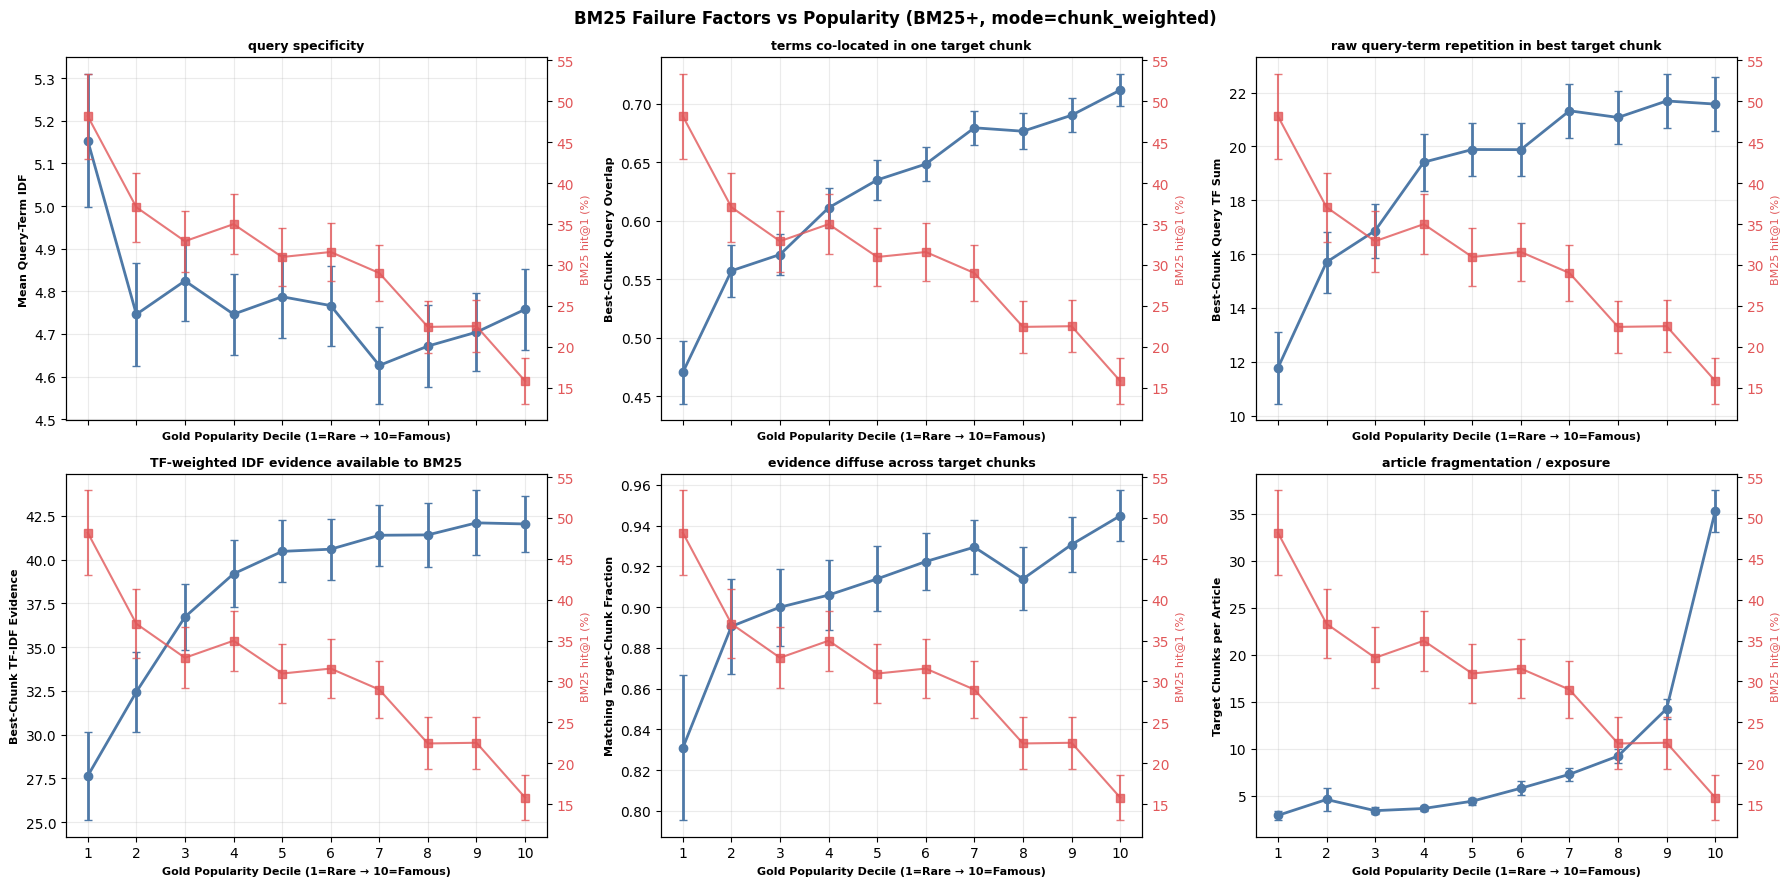

✓ Saved → bm25_failure_factors_retrieved_docs_bm25_plus.png


In [6]:
FACTOR_PANELS = [
    ('query_idf_mean', 'Mean Query-Term IDF', 'query specificity'),
    ('best_chunk_query_overlap_frac', 'Best-Chunk Query Overlap', 'terms co-located in one target chunk'),
    ('best_chunk_query_tf_sum', 'Best-Chunk Query TF Sum', 'raw query-term repetition in best target chunk'),
    ('best_chunk_query_tfidf_sum', 'Best-Chunk TF-IDF Evidence', 'TF-weighted IDF evidence available to BM25'),
    ('matching_chunk_frac', 'Matching Target-Chunk Fraction', 'evidence diffuse across target chunks'),
    ('n_chunks', 'Target Chunks per Article', 'article fragmentation / exposure'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
axes = axes.ravel()
x = factor_summary['decile_label'].to_numpy()
recall = factor_summary['hit_at_1'].to_numpy() * 100.0

for ax, (col, ylabel, subtitle) in zip(axes, FACTOR_PANELS):
    y = factor_summary[col].to_numpy(dtype=float)
    yerr = factor_summary[f'{col}_ci95'].to_numpy(dtype=float)
    ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2.0, color='#4e79a7',
                capsize=3, label=ylabel)
    ax.set_xlabel('Gold Popularity Decile (1=Rare → 10=Famous)', fontsize=8, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8, fontweight='bold')
    ax.set_title(subtitle, fontsize=9, fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.grid(alpha=0.25)

    ax2 = ax.twinx()
    ax2.errorbar(x, recall, yerr=factor_summary['hit_at_1_ci95'].to_numpy(dtype=float) * 100.0,
                 marker='s', linewidth=1.5, color='#e15759', alpha=0.80, capsize=3,
                 label='BM25 hit@1')
    ax2.set_ylabel('BM25 hit@1 (%)', fontsize=8, color='#e15759')
    ax2.tick_params(axis='y', labelcolor='#e15759')

fig.suptitle(
    f'BM25 Failure Factors vs Popularity ({strategy_label(BM25_STRATEGY)}, mode={DECILE_MODE})',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
out = IMAGES_DIR / f'bm25_failure_factors_{BM25_STRATEGY}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

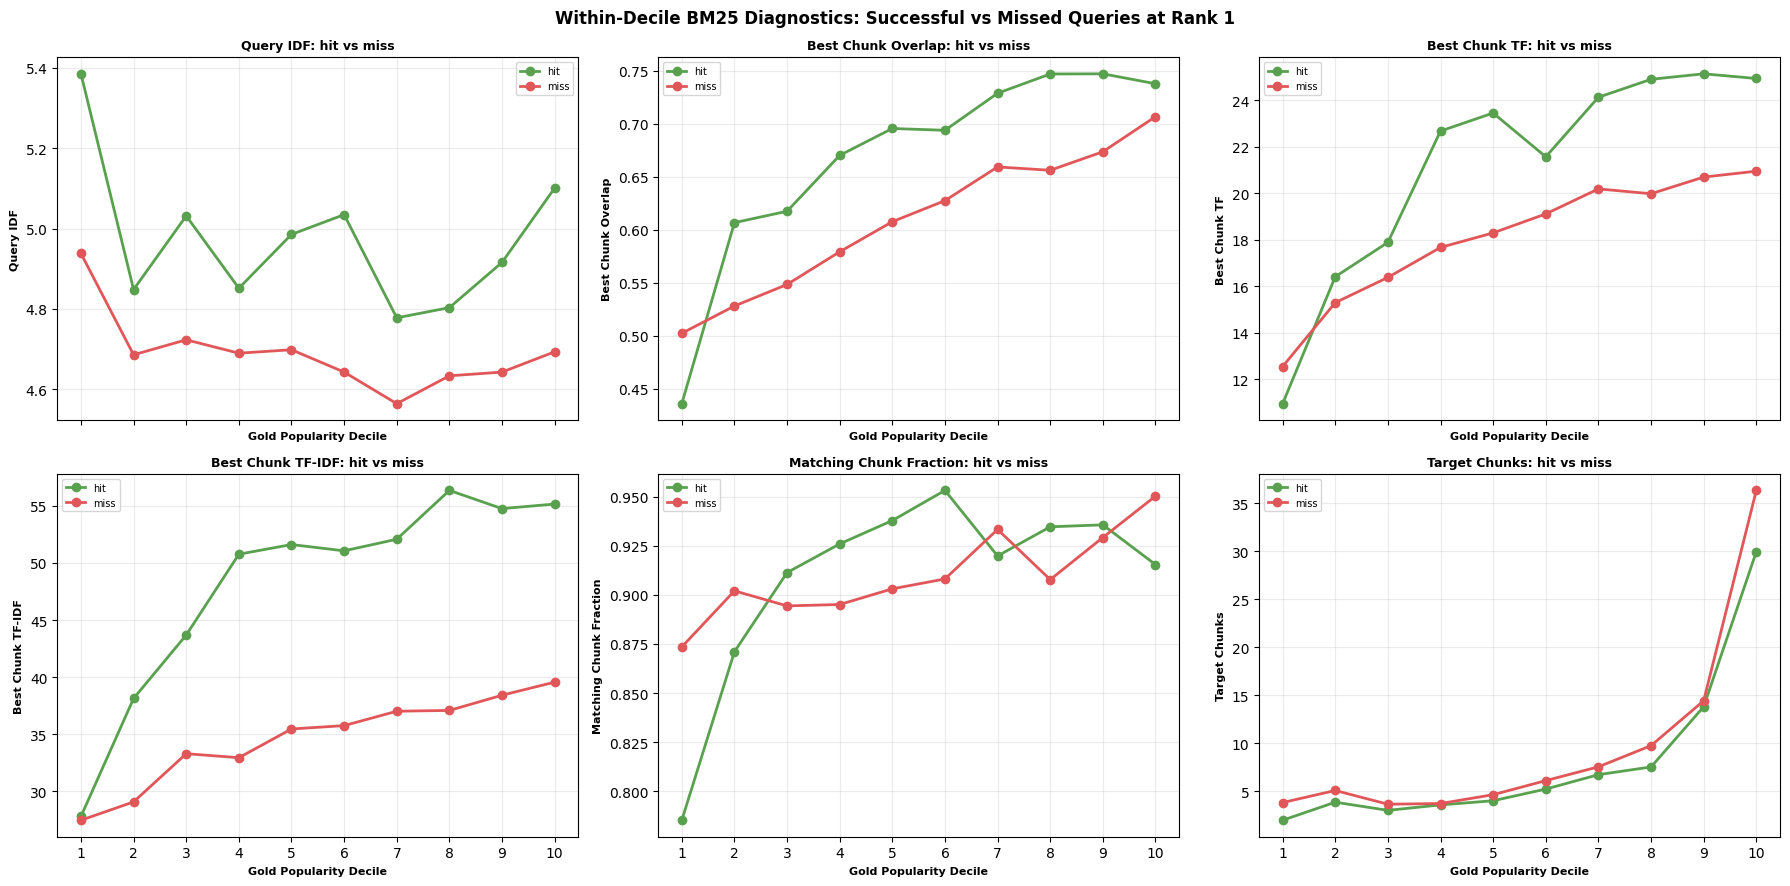

✓ Saved → bm25_hit_vs_miss_factors_retrieved_docs_bm25_plus.png


In [7]:
HIT_MISS_PANELS = [
    ('mean_query_idf_mean', 'Query IDF'),
    ('mean_best_chunk_query_overlap_frac', 'Best Chunk Overlap'),
    ('mean_best_chunk_query_tf_sum', 'Best Chunk TF'),
    ('mean_best_chunk_query_tfidf_sum', 'Best Chunk TF-IDF'),
    ('mean_matching_chunk_frac', 'Matching Chunk Fraction'),
    ('mean_n_chunks', 'Target Chunks'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
axes = axes.ravel()
colors = {'hit': '#59a14f', 'miss': '#e15759'}
for ax, (col, ylabel) in zip(axes, HIT_MISS_PANELS):
    for outcome in ['hit', 'miss']:
        sub = hit_miss_summary[hit_miss_summary['outcome'] == outcome]
        ax.plot(
            sub['decile'] + 1,
            sub[col],
            marker='o',
            linewidth=2.0,
            color=colors[outcome],
            label=outcome,
        )
    ax.set_xlabel('Gold Popularity Decile', fontsize=8, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8, fontweight='bold')
    ax.set_title(f'{ylabel}: hit vs miss', fontsize=9, fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7)

fig.suptitle(
    'Within-Decile BM25 Diagnostics: Successful vs Missed Queries at Rank 1',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
out = IMAGES_DIR / f'bm25_hit_vs_miss_factors_{BM25_STRATEGY}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

,factor,corr_with_hit_at_1_across_deciles,decile_1_value,decile_10_value,delta_10_minus_1
1,best_chunk_query_overlap_frac,-0.9356,0.4704,0.7118,0.2413
4,matching_chunk_frac,-0.8971,0.8309,0.9448,0.1138
2,best_chunk_query_tf_sum,-0.8863,11.7703,21.5753,9.8050
3,best_chunk_query_tfidf_sum,-0.8665,27.6439,42.0304,14.3865
5,n_chunks,-0.7621,2.9188,35.3027,32.3839
0,query_idf_mean,0.7186,5.1536,4.7577,-0.3959


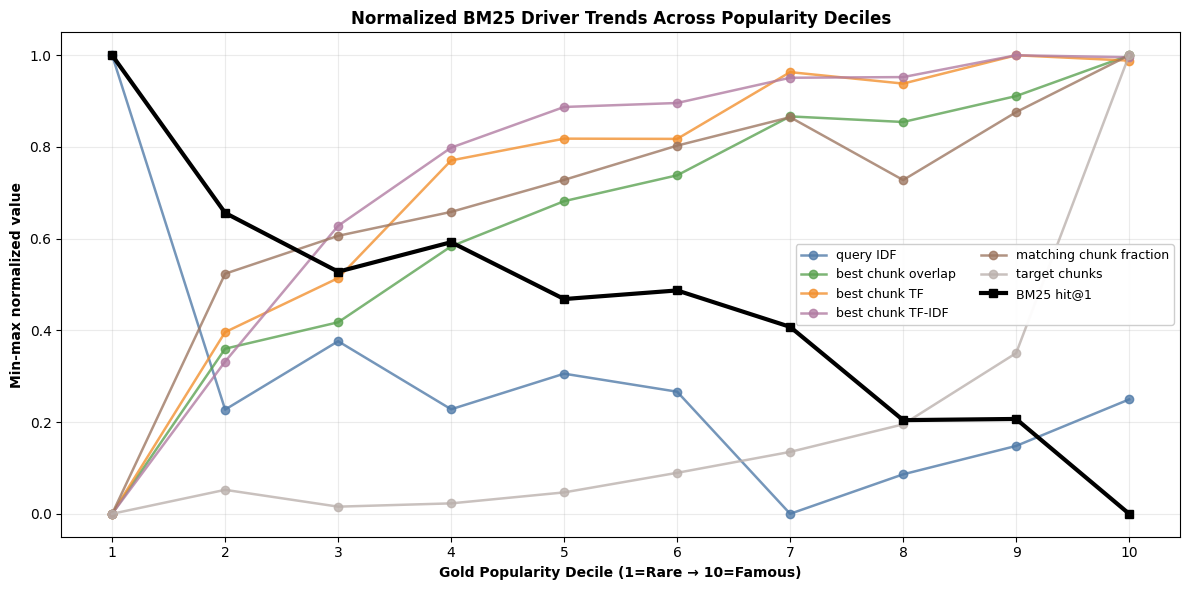

✓ Saved → bm25_normalized_driver_trends_retrieved_docs_bm25_plus.png


In [8]:
DRIVER_COLS = [
    'query_idf_mean',
    'best_chunk_query_overlap_frac',
    'best_chunk_query_tf_sum',
    'best_chunk_query_tfidf_sum',
    'matching_chunk_frac',
    'n_chunks',
]

driver_df = factor_summary[['decile_label', 'hit_at_1'] + DRIVER_COLS].copy()
norm_df = driver_df.copy()
for col in DRIVER_COLS + ['hit_at_1']:
    vals = norm_df[col].astype(float)
    span = vals.max() - vals.min()
    norm_df[col] = (vals - vals.min()) / span if span > 0 else 0.0

corr_rows = []
for col in DRIVER_COLS:
    corr_rows.append({
        'factor': col,
        'corr_with_hit_at_1_across_deciles': driver_df[col].corr(driver_df['hit_at_1']),
        'decile_1_value': driver_df.loc[driver_df['decile_label'] == 1, col].iloc[0],
        'decile_10_value': driver_df.loc[driver_df['decile_label'] == 10, col].iloc[0],
        'delta_10_minus_1': driver_df.loc[driver_df['decile_label'] == 10, col].iloc[0] - driver_df.loc[driver_df['decile_label'] == 1, col].iloc[0],
    })
corr_df = pd.DataFrame(corr_rows).sort_values('corr_with_hit_at_1_across_deciles')
display(corr_df.round(4))

fig, ax = plt.subplots(figsize=(12, 6))
style_map = {
    'query_idf_mean': ('#4e79a7', 'query IDF'),
    'best_chunk_query_overlap_frac': ('#59a14f', 'best chunk overlap'),
    'best_chunk_query_tf_sum': ('#f28e2b', 'best chunk TF'),
    'best_chunk_query_tfidf_sum': ('#b07aa1', 'best chunk TF-IDF'),
    'matching_chunk_frac': ('#9c755f', 'matching chunk fraction'),
    'n_chunks': ('#bab0ac', 'target chunks'),
}
for col in DRIVER_COLS:
    color, label = style_map[col]
    ax.plot(norm_df['decile_label'], norm_df[col], marker='o', linewidth=1.8, alpha=0.78, color=color, label=label)
ax.plot(norm_df['decile_label'], norm_df['hit_at_1'], color='black', marker='s', linewidth=3.0, label='BM25 hit@1')
ax.set_xlabel('Gold Popularity Decile (1=Rare → 10=Famous)', fontweight='bold')
ax.set_ylabel('Min-max normalized value', fontweight='bold')
ax.set_title('Normalized BM25 Driver Trends Across Popularity Deciles', fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=9, framealpha=0.95)
plt.tight_layout()
out = IMAGES_DIR / f'bm25_normalized_driver_trends_{BM25_STRATEGY}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## BM25 Minimal Mechanism Check: IDF, TF, Competition

This compact figure isolates three BM25-relevant mechanisms: how rare terms are inside chunks, how often terms repeat inside chunks, and how many same-decile chunks compete for each evaluation question. The red line overlays BM25 hit@1 so the diagnostic trend can be compared directly to retrieval performance.

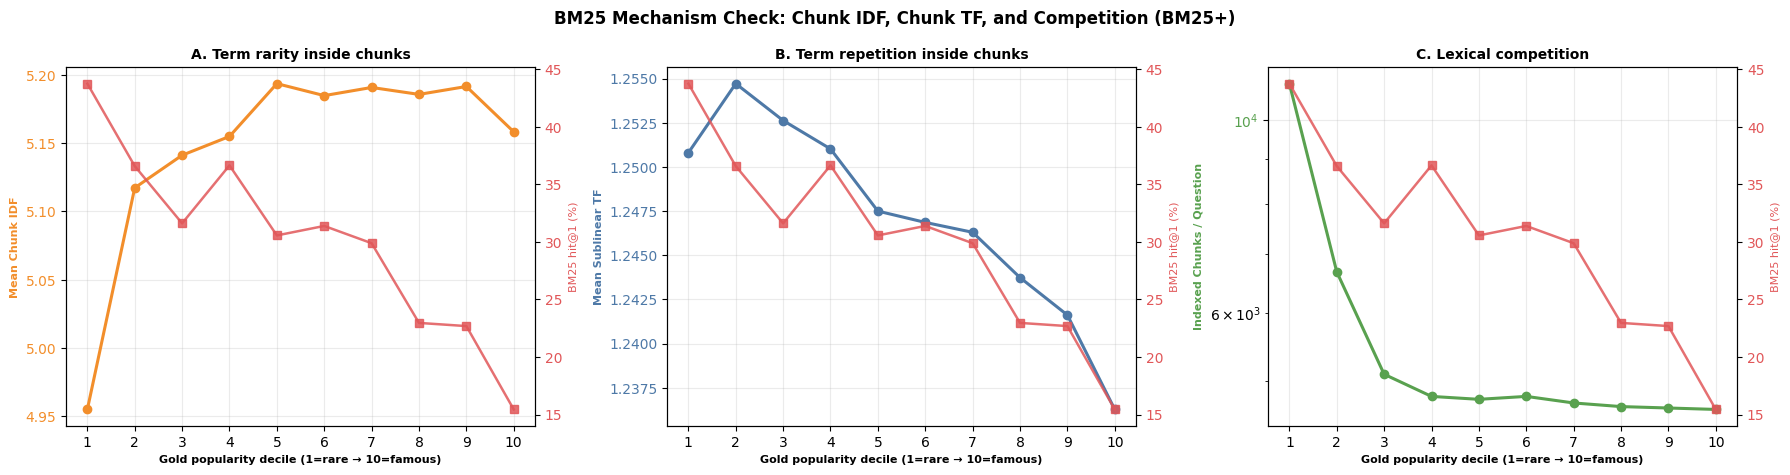

✓ Saved → bm25_idf_tf_competition_retrieved_docs_bm25_plus.png


In [9]:
BM25_STRATEGY = next((s for s in ALL_STRATEGIES if 'bm25' in s.lower()), ALL_STRATEGIES[0])
bm25_df = results_by_strategy[BM25_STRATEGY]
questions_per_decile = np.array(
    [int((bm25_df[decile_col] == d).sum()) for d in range(10)],
    dtype=float,
)
hit_at_1 = np.array([
    float(bm25_df.loc[bm25_df[decile_col] == d, 'recall@1'].mean())
    if int((bm25_df[decile_col] == d).sum()) else np.nan
    for d in range(10)
])
mean_chunk_idf = np.array([
    tfidf_stats.get(str(d), {}).get('mean_idf_of_used_terms', np.nan)
    for d in range(10)
], dtype=float)
mean_chunk_tf = np.array([
    tfidf_stats.get(str(d), {}).get('mean_tf_score', np.nan)
    for d in range(10)
], dtype=float)
competition_chunks_per_question = np.divide(
    np.asarray(corpus_chunks, dtype=float),
    questions_per_decile,
    out=np.full(10, np.nan, dtype=float),
    where=questions_per_decile > 0,
)

MECHANISM_PANELS = [
    (mean_chunk_idf, 'Mean Chunk IDF', 'A. Term rarity inside chunks', '#f28e2b', False),
    (mean_chunk_tf, 'Mean Sublinear TF', 'B. Term repetition inside chunks', '#4e79a7', False),
    (competition_chunks_per_question, 'Indexed Chunks / Question', 'C. Lexical competition', '#59a14f', True),
]

x = np.arange(1, 11)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
for ax, (values, ylabel, title, color, log_scale) in zip(axes, MECHANISM_PANELS):
    ax.plot(x, values, marker='o', linewidth=2.2, color=color)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Gold popularity decile (1=rare → 10=famous)', fontsize=8, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8, fontweight='bold', color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.set_xticks(x)
    if log_scale:
        ax.set_yscale('log')
    ax.grid(alpha=0.25)

    ax2 = ax.twinx()
    ax2.plot(x, hit_at_1 * 100.0, marker='s', linewidth=1.8, color='#e15759', alpha=0.85)
    ax2.set_ylabel('BM25 hit@1 (%)', fontsize=8, color='#e15759')
    ax2.tick_params(axis='y', labelcolor='#e15759')

fig.suptitle(
    f'BM25 Mechanism Check: Chunk IDF, Chunk TF, and Competition ({strategy_label(BM25_STRATEGY)})',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
out = IMAGES_DIR / f'bm25_idf_tf_competition_{BM25_STRATEGY}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## BM25 Focus Check: Query IDF, Best-Chunk Query TF, Matched-Chunk Fraction

This figure focuses on the three clearest BM25 failure explanations: query specificity, how much the query terms repeat in the best matching target chunk, and how much of the target article is touched by the query. If BM25 gets worse while query IDF falls, even rising target-side TF/coverage can mean the target article is rich but the question is not discriminative enough. Vertical bars show 95% normal confidence intervals over questions.

,decile,n,hit_at_1,hit_at_1_ci95,query_idf_mean,query_idf_mean_ci95,best_chunk_query_tf_sum,best_chunk_query_tf_sum_ci95,best_chunk_query_log_tf_sum,best_chunk_query_log_tf_sum_ci95,matching_chunk_frac,matching_chunk_frac_ci95,decile_label
0,0,357,0.4818,0.0518,5.1536,0.1569,11.7703,1.3286,6.5996,0.6141,0.8309,0.0355,1
1,1,502,0.3705,0.0422,4.7460,0.1202,15.7012,1.1381,8.7002,0.5637,0.8905,0.0232,2
2,2,617,0.3290,0.0371,4.8246,0.0948,16.8703,1.0023,9.1566,0.4619,0.8999,0.0189,3
3,3,646,0.3498,0.0368,4.7463,0.0951,19.4164,1.0629,10.0581,0.4756,0.9059,0.0173,4
4,4,649,0.3097,0.0356,4.7873,0.0970,19.8875,0.9931,10.2055,0.4325,0.9138,0.0160,5
5,5,646,0.3158,0.0358,4.7665,0.0940,19.8824,0.9924,10.2477,0.4148,0.9223,0.0141,6
6,6,655,0.2901,0.0348,4.6261,0.0897,21.3267,1.0065,10.8722,0.4307,0.9294,0.0133,7
7,7,660,0.2242,0.0318,4.6715,0.0953,21.0788,0.9876,10.8845,0.4499,0.9138,0.0155,8
8,8,662,0.2251,0.0318,4.7042,0.0923,21.6918,1.0084,10.9935,0.4427,0.9306,0.0135,9
9,9,664,0.1581,0.0278,4.7577,0.0945,21.5753,0.9965,10.9009,0.4181,0.9448,0.0125,10


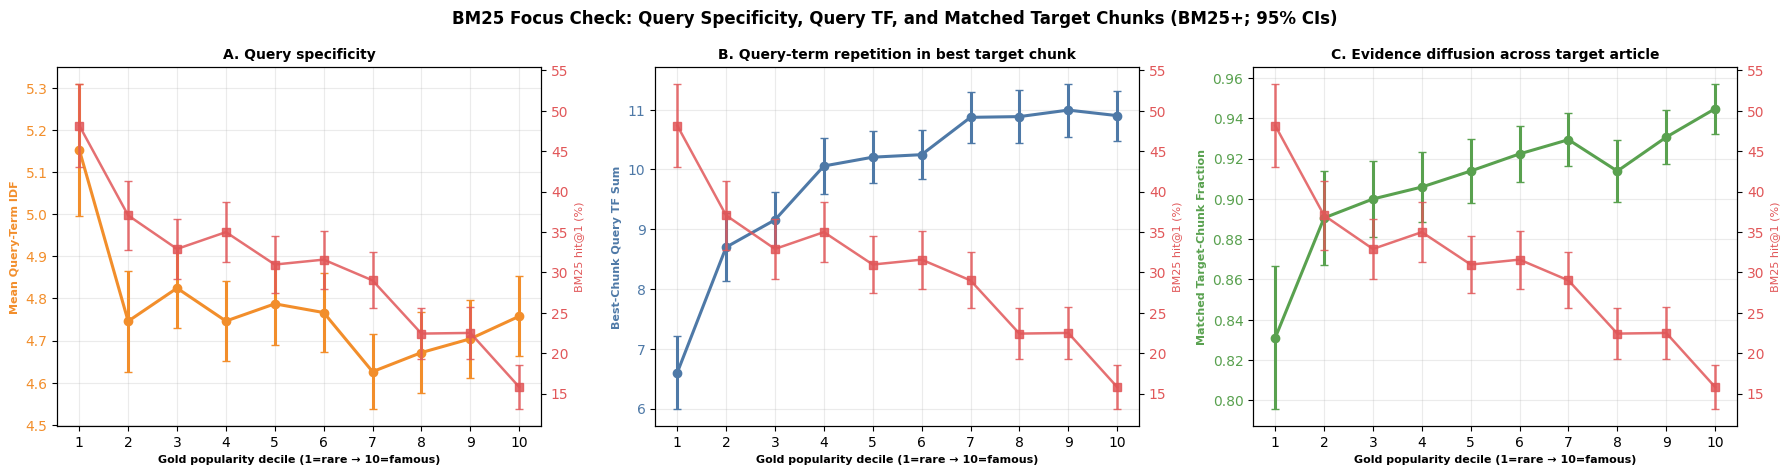

✓ Saved → bm25_query_idf_tf_matching_retrieved_docs_bm25_plus.png


In [10]:
# Requires the BM25 Failure Factor Analysis cell above to have produced bm25_factors.
focus_columns = [
    'decile', 'n', 'hit_at_1', 'hit_at_1_ci95',
    'query_idf_mean', 'query_idf_mean_ci95',
    'best_chunk_query_tf_sum', 'best_chunk_query_tf_sum_ci95',
    'best_chunk_query_log_tf_sum', 'best_chunk_query_log_tf_sum_ci95',
    'matching_chunk_frac', 'matching_chunk_frac_ci95',
]
focus_summary = factor_summary[focus_columns].copy()
focus_summary['decile_label'] = focus_summary['decile'] + 1
display(focus_summary.round(4))

FOCUS_PANELS = [
    ('query_idf_mean', 'Mean Query-Term IDF', 'A. Query specificity', '#f28e2b'),
    ('best_chunk_query_log_tf_sum', 'Best-Chunk Query TF Sum', 'B. Query-term repetition in best target chunk', '#4e79a7'),
    ('matching_chunk_frac', 'Matched Target-Chunk Fraction', 'C. Evidence diffusion across target article', '#59a14f'),
]

x = focus_summary['decile_label'].to_numpy()
hit_at_1_pct = focus_summary['hit_at_1'].to_numpy(dtype=float) * 100.0
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)

for ax, (col, ylabel, title, color) in zip(axes, FOCUS_PANELS):
    vals = focus_summary[col].to_numpy(dtype=float)
    errs = focus_summary[f'{col}_ci95'].to_numpy(dtype=float)
    ax.errorbar(x, vals, yerr=errs, marker='o', linewidth=2.2, color=color, capsize=3)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Gold popularity decile (1=rare → 10=famous)', fontsize=8, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8, fontweight='bold', color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.set_xticks(range(1, 11))
    ax.grid(alpha=0.25)

    ax2 = ax.twinx()
    ax2.errorbar(x, hit_at_1_pct,
                 yerr=focus_summary['hit_at_1_ci95'].to_numpy(dtype=float) * 100.0,
                 marker='s', linewidth=1.8, color='#e15759', alpha=0.85, capsize=3)
    ax2.set_ylabel('BM25 hit@1 (%)', fontsize=8, color='#e15759')
    ax2.tick_params(axis='y', labelcolor='#e15759')

fig.suptitle(
    f'BM25 Focus Check: Query Specificity, Query TF, and Matched Target Chunks ({strategy_label(BM25_STRATEGY)}; 95% CIs)',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
out = IMAGES_DIR / f'bm25_query_idf_tf_matching_{BM25_STRATEGY}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## Retrieval Difficulty Per Decile

✓ Saved → /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k/eval_results/retrieval_difficulty_per_decile.png


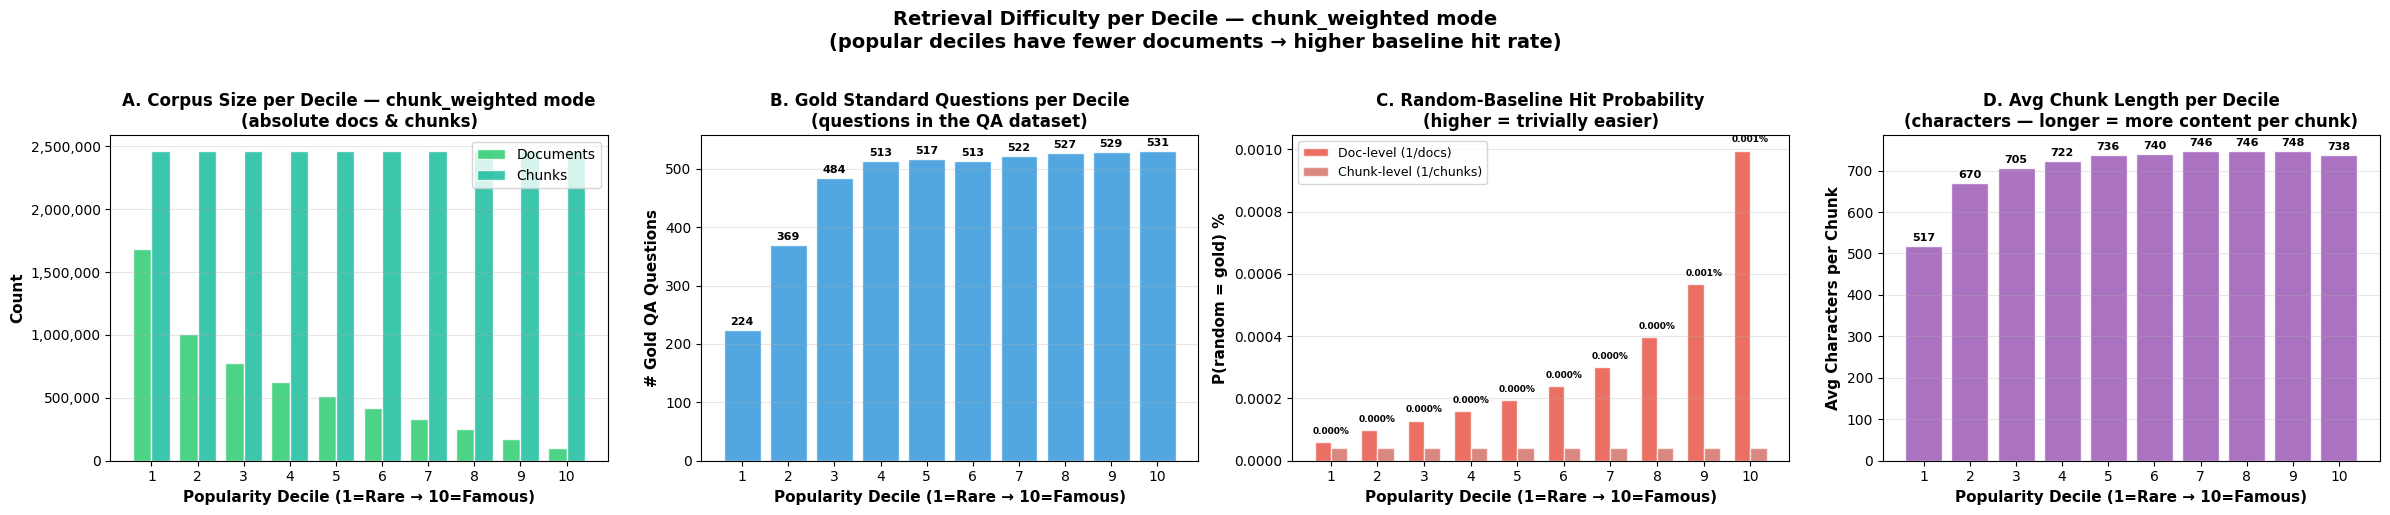

✓ Saved → retrieval_difficulty_per_decile.png


In [11]:
from src.metrics.tfidf_service import plot_retrieval_difficulty

results_df = results_by_strategy[ALL_STRATEGIES[0]]

fig = plot_retrieval_difficulty(
    corpus_docs=corpus_docs,
    corpus_chunks=corpus_chunks,
    questions_per_decile=np.array(
        [results_df[decile_col].value_counts().get(d, 0) for d in range(10)], dtype=float
    ),
    tfidf_stats=tfidf_stats,
    decile_mode=DECILE_MODE,
    out_path=IMAGES_DIR / 'retrieval_difficulty_per_decile.png',
)
plt.show()
print('✓ Saved → retrieval_difficulty_per_decile.png')